# FCS Fitting Notebook

A notebook for simple FCS fitting.
Any model which you wish to include should be written in the script `fcs_plotting`.

Package requirements:
- matplotlib
- numpy
- lmfit

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from lmfit import Model, Parameters

from fcs_models import *
from fcs_plotting import *

This is where you change all of the variables for the script.

For a standard fitting, change the variable `FILEPATH` to the location of the .txt file you wish to fit (the first column is assumed to be the lag time, the second to fifth the correlation functions and sixth to ninth the standard deviations).
Then, change the `MODEL` to whatever model you wish to use to fit the curve.
`lmfit` allows for fitting bounds to be implemented (https://lmfit.github.io/lmfit-py/bounds.html), and typical regimes are included in `VALUE_BOUNDS` in SI units (distance: metres, time: seconds).

If you are performing a calibration measurement, use model functions ending in `_fixD` such that the script will automatically force the diffusion coefficient to be whatever value you set in `DEFAULT_VALUES`.
Standard diffusion coefficients of dyes can be found here: https://www.picoquant.com/images/uploads/page/files/7353/appnote_diffusioncoefficients.pdf

In [2]:
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 16
plt.rcParams['text.usetex'] = True # use LaTeX for all text. If you don't have LaTeX installed, you can set this to False
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

TIME_BOUNDS = [1e-7, 1e-1] # upper and lower bounds for lag times to be fitted in seconds
FILEPATH = r"C:\Users\aiyan\Downloads\Atto655_10nM_new_xR_OD1_10_FCS.txt"

COLORS = ["#007FA3", "#6D247A", "#DC4633", "#8DBF2E"]
LABELS = ['CF1', 'CF2', 'CF3', 'CF4']

MODEL = CF_3d_gauss_1T_fixD
DEFAULT_VALUES = {'n': 1, 'tauD': 1e-5, 'D' : 4.25e-10, 'r0' : 2e-7, 's' : 5, 'offset' : 0, 'tautr1' : 1e-5, 'T1' : 0.1, 'tautr2' : 1e-6, 'T2' : 0.1}
VALUE_BOUNDS = {'n': [0.001, 1000], 'tauD': [1e-7, 1e-2], 'D': [1e-13,1e-9], 'r0' : [1e-9,1e-6], 's': [1, 20], 'offset' : [-1, 1], 'tautr1' : [1e-8, 1e-3], 'T1' : [1e-7, 0.8], 'tautr2' : [1e-8, 1e-3], 'T2' : [1e-7, 0.8]}
VARY = {'n': True, 'tauD': True, 'D': True, 'r0' : True, 's' : True, 'offset' : True, 'tautr1' : True, 'T1' : True, 'tautr2' : True, 'T2' : True}

In [3]:
CURR_PARAMS = MODEL.__code__.co_varnames[1:MODEL.__code__.co_argcount]
params = Parameters()
for param in CURR_PARAMS:
    if "fixD" in MODEL.__name__ and param == "D":
        params.add(param, value=DEFAULT_VALUES[param], vary=False, min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
    else:
        params.add(param, value=DEFAULT_VALUES[param], vary=VARY[param], min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
params

name,value,initial value,min,max,vary
n,1.00000000,1,1.0000e-03,1000.00000,True
D,4.2500e-10,4.25e-10,1.0000e-13,1.0000e-09,False
r0,2.0000e-07,2e-07,1.0000e-09,1.0000e-06,True
s,5.00000000,5,1.00000000,20.0000000,True
offset,0.00000000,0,-1.00000000,1.00000000,True
tautr1,1.0000e-05,1e-05,1.0000e-08,1.0000e-03,True
T1,0.10000000,0.1,1.0000e-07,0.80000000,True


In [4]:
data = np.loadtxt(FILEPATH)

In [5]:
lag_times = data[:,0]
masked_times = np.logical_and(lag_times > TIME_BOUNDS[0], lag_times < TIME_BOUNDS[1])
select_data = data[masked_times]

In [6]:
lag_times = select_data[:,0]
cf1 = select_data[:,1]
errors1 = select_data[:,5]
cf2 = select_data[:,2]
errors2 = select_data[:,6]
cf3 = select_data[:,3]
errors3 = select_data[:,7]
cf4 = select_data[:,4]
errors4 = select_data[:,8]

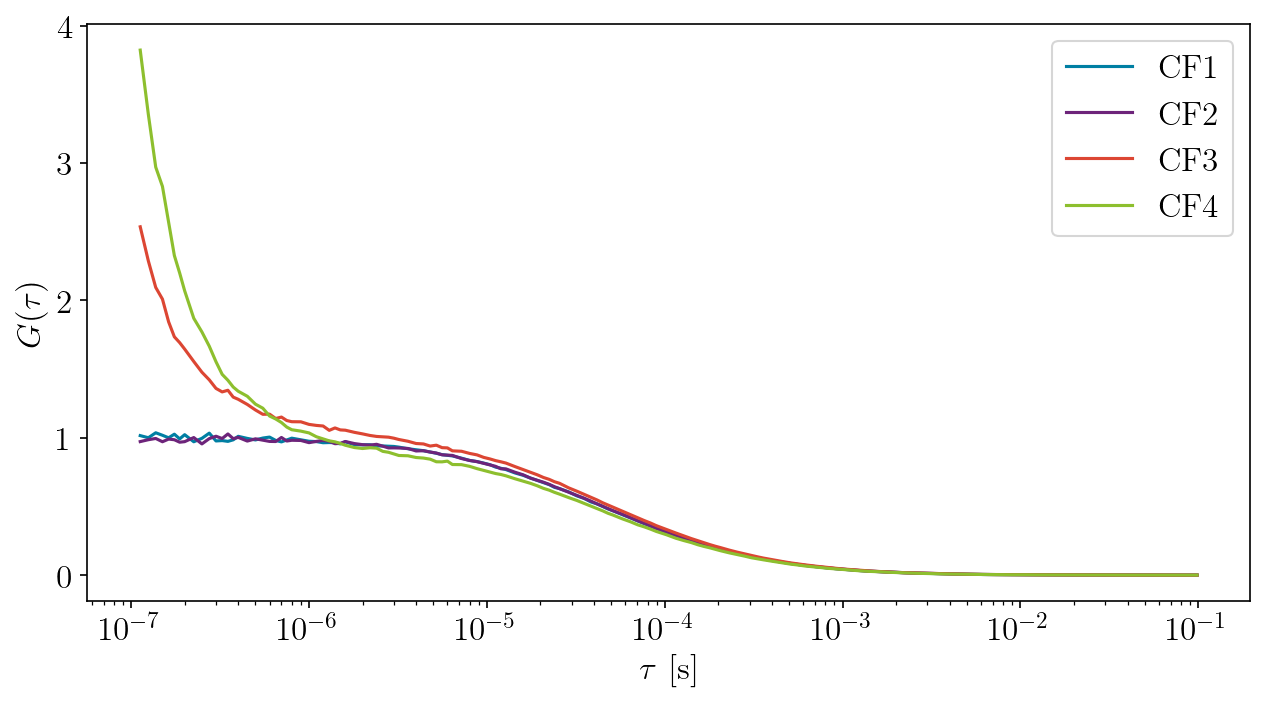

In [7]:
fig1 = plt.figure(1)

plt.plot(lag_times, cf1, label=LABELS[0], color=COLORS[0])
plt.plot(lag_times, cf2, label=LABELS[1], color=COLORS[1])
plt.plot(lag_times, cf3, label=LABELS[2], color=COLORS[2])
plt.plot(lag_times, cf4, label=LABELS[3], color=COLORS[3])
plt.semilogx()
plt.legend()
plt.xlabel(r'$\tau$ [s]')
plt.ylabel(r'$G(\tau)$')
plt.show()

In [8]:
model1 = Model(MODEL)
model2 = Model(MODEL)
model3 = Model(MODEL)
model4 = Model(MODEL)

In [9]:
result1 = model1.fit(cf1, params, taus=lag_times)
result2 = model2.fit(cf2, params, taus=lag_times)

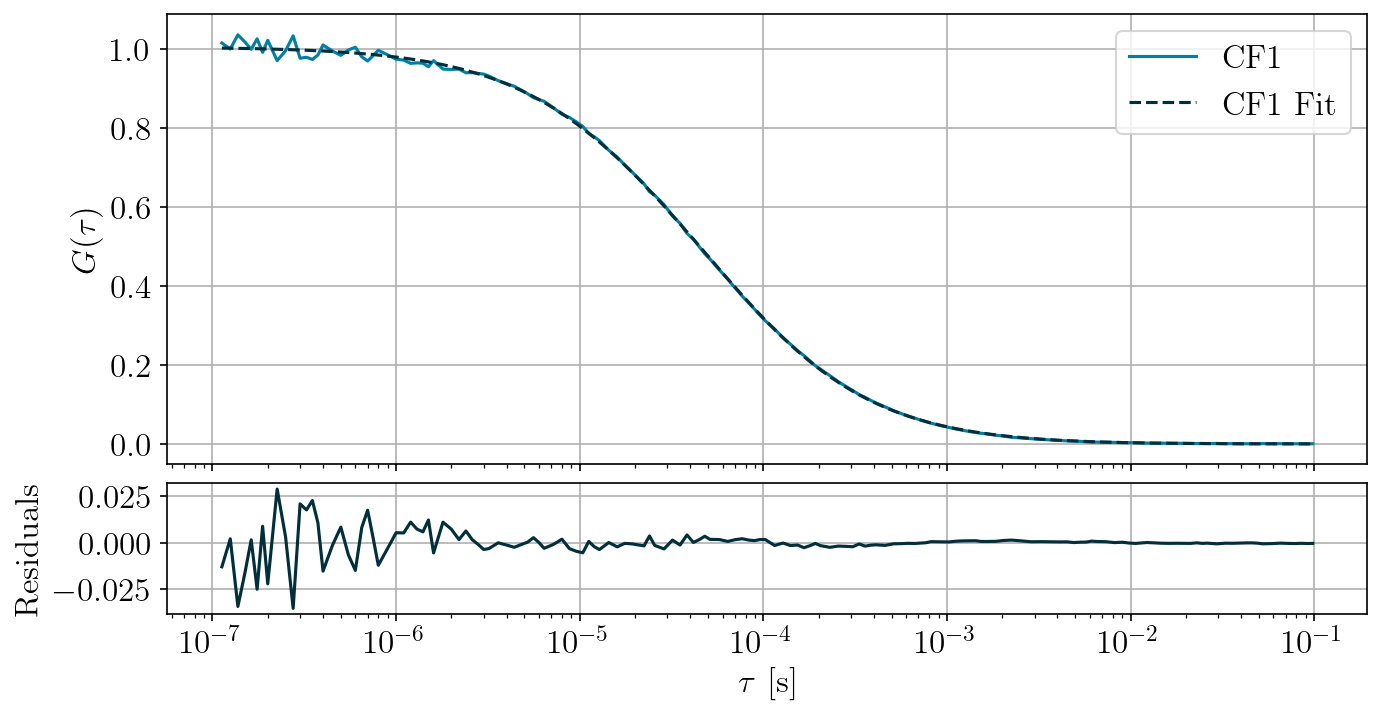

n,1.0780,None
D,425.0000,um2/s
r0,300.1331,nm
s,11.2459,None
offset,-0.0002,None
tautr1,10.4479,us
T1,0.0778,None
tauD,0.0530,ms
C,1.0573,nM
Reduced Chi-Squared,0.0001,None
AIC,-1555.0190,None


In [10]:
model_plot(lag_times, cf1, result1, LABELS[0], COLORS[0])
interpret_fit(result1)

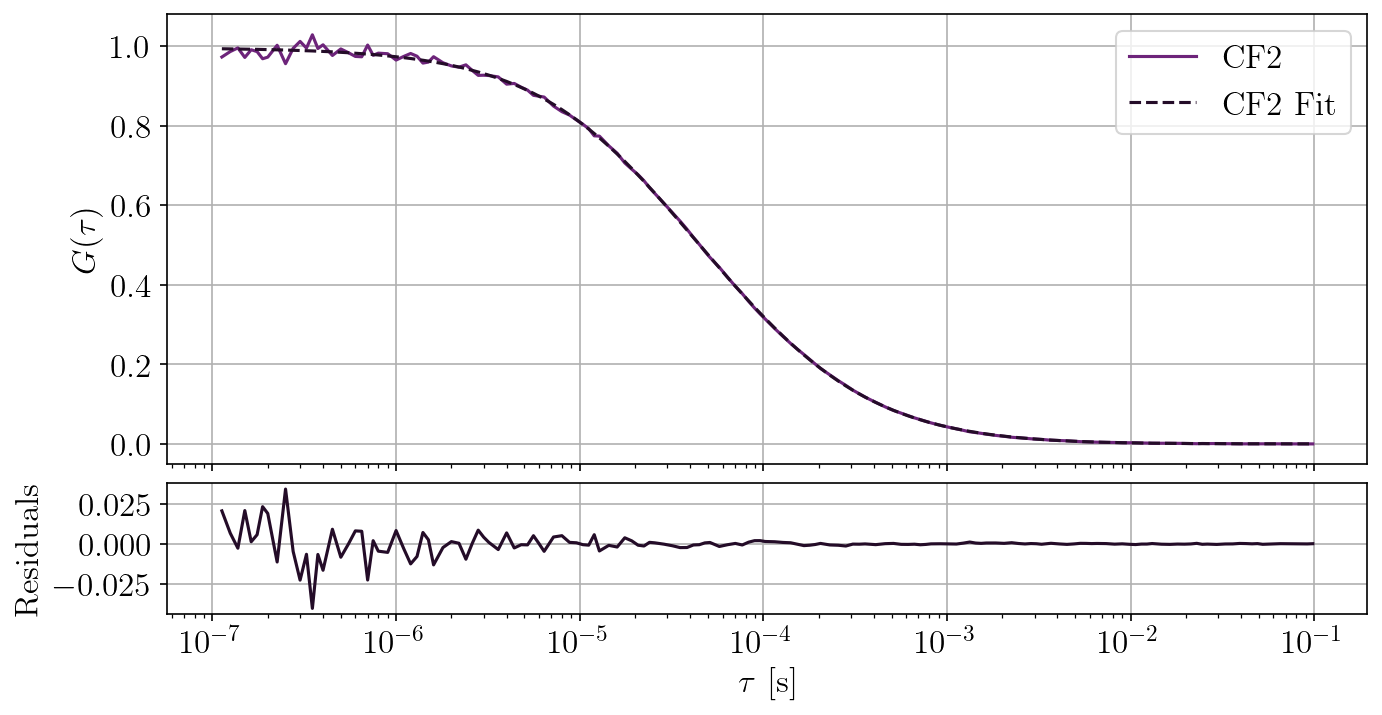

n,1.1425,None
D,425.0000,um2/s
r0,316.3883,nm
s,7.6753,None
offset,0.0002,None
tautr1,19.5256,us
T1,0.1205,None
tauD,0.0589,ms
C,1.4016,nM
Reduced Chi-Squared,0.0000,None
AIC,-1570.3256,None


In [11]:
model_plot(lag_times, cf2, result2, LABELS[1], COLORS[1])
interpret_fit(result2)